In [1]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from scipy import stats

import torch
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns

from model import Autoencoder
from pipeline import train_ae_with_early_stopping, compute_reconstruction_errors

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_DIR = Path("../data")


In [ ]:
def load_dataset_pair(name: str):
    src_path = DATA_DIR / f"{name}_source.csv"
    tgt_path = DATA_DIR / f"{name}_target.csv"
    ID_df = pd.read_csv(src_path)
    OOD_df = pd.read_csv(tgt_path)

    ID_df = ID_df.select_dtypes(include=[np.number]).dropna()
    OOD_df = OOD_df.select_dtypes(include=[np.number]).dropna()

    print(f"ID shape: {ID_df.shape}, OOD shape: {OOD_df.shape}")
    return ID_df, OOD_df


In [ ]:
def fit_autoencoder_for_ood(
    ID_df: pd.DataFrame,
    OOD_df: pd.DataFrame,
    latent_dim: int = 3,
    hidden_dims = [64, 32],
    batch_size: int = 32,
    test_size: float = 0.3,
    val_size: float = 0.5,
    lr: float = 1e-3,
    epochs: int = 1000,
    patience: int = 30,
    random_state: int = 42,
):
    input_dim = ID_df.shape[1]

    ID_train_val, ID_test = train_test_split(
        ID_df, test_size=test_size, random_state=random_state
    )
    OOD_test, _ = train_test_split(
        OOD_df, test_size=test_size, random_state=random_state
    )
    
   
    X_train, X_val = train_test_split(
        ID_train_val, test_size=val_size, random_state=random_state
    )

    print("=" * 70)
    print("РАЗБИЕНИЕ ДАННЫХ")
    print("=" * 70)
    print(f"Train (ID): {X_train.shape}")
    print(f"Validation (ID): {X_val.shape}")
    print(f"Test ID: {ID_test.shape}")
    print(f"Test OOD: {OOD_test.shape}")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_ID_scaled = scaler.transform(ID_test)
    X_test_OOD_scaled = scaler.transform(OOD_test)

    train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_scaled)), batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(TensorDataset(torch.FloatTensor(X_val_scaled)),   batch_size=batch_size, shuffle=False)
    test_ID_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test_ID_scaled)), batch_size=batch_size, shuffle=False)
    test_OOD_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test_OOD_scaled)), batch_size=batch_size, shuffle=False)

    print("\n" + "=" * 70)
    print("ОБУЧЕНИЕ АВТОЭНКОДЕРА")
    print("=" * 70)
    model = Autoencoder(input_dim=input_dim, latent_dim=latent_dim, hidden_dims=hidden_dims)
    model.to(device)

    model, train_losses, val_losses = train_ae_with_early_stopping(
        model, train_loader, val_loader,
        epochs=epochs, patience=patience, lr=lr
    )

    
    ID_errors  = compute_reconstruction_errors(model, test_ID_loader, device)
    OOD_errors = compute_reconstruction_errors(model, test_OOD_loader, device)

    print("\n" + "=" * 70)
    print("KS-ТЕСТ ДЛЯ ТЕСТОВОЙ ВЫБОРКИ")
    print("=" * 70)
    ks_stat, p_val = stats.ks_2samp(ID_errors, OOD_errors)
    print(f"KS statistic = {ks_stat:.6f}, p-value = {p_val:.6f}")

    return {
        "model": model,
        "scaler": scaler,
        "X_train": X_train,
        "X_val": X_val,
        "X_test_ID": ID_test,
        "X_test_OOD": OOD_test,
        "ID_errors": ID_errors,
        "OOD_errors": OOD_errors,
    }


In [ ]:
def ks_bucket_ood_scores(
    X: pd.DataFrame,
    recon_errors: np.ndarray,
    ref_errors: np.ndarray,
    m: int = 50,
    n_bins: int = 5,
    alpha: float = 0.05,
    min_bucket_size: int = 30,
    random_state: int | None = 42,
):
    X = X.reset_index(drop=True)
    recon_errors = np.asarray(recon_errors)
    ref_errors = np.asarray(ref_errors)

    assert len(X) == len(recon_errors)

    rng = np.random.default_rng(random_state)
    n_samples, n_features = X.shape

    
    times_in_buckets = np.zeros(n_samples, dtype=int)
    ood_bucket_hits = np.zeros(n_samples, dtype=int)

    feature_indices = rng.integers(0, n_features, size=m)

    for split_idx, feat_idx in enumerate(feature_indices):
        feature_values = X.iloc[:, feat_idx]

        try:
            quantiles = np.linspace(0.0, 1.0, n_bins + 1)
            bin_edges = np.unique(np.quantile(feature_values, quantiles))

        if len(bin_edges) <= 1:
            continue

        bucket_ids = pd.cut(
            feature_values,
            bins=bin_edges,
            include_lowest=True,
            labels=False
        )

        for b in np.unique(bucket_ids.dropna()):
            mask = (bucket_ids == b).to_numpy()
            idx = np.where(mask)[0]

            if len(idx) < min_bucket_size:
                continue

            bucket_errors = recon_errors[idx]
            
            p_val = stats.ks_2samp(ref_errors, bucket_errors)[1]
            is_ood_bucket = p_val <= alpha

            
            times_in_buckets[idx] += 1
            if is_ood_bucket:
                ood_bucket_hits[idx] += 1

    # доля срабатываний по каждому объекту
    with np.errstate(divide="ignore", invalid="ignore"):
        scores = np.zeros_like(ood_bucket_hits, dtype=float)
        valid_mask = times_in_buckets > 0
        scores[valid_mask] = ood_bucket_hits[valid_mask] / times_in_buckets[valid_mask]

    return {
        "scores": scores,
        "ood_bucket_hits": ood_bucket_hits,
        "times_in_buckets": times_in_buckets,
        "feature_indices": feature_indices,
    }


SyntaxError: invalid syntax (1797369801.py, line 28)

ID shape: (10000, 9), OOD shape: (10000, 9)
РАЗБИЕНИЕ ДАННЫХ
Train (ID): (3500, 9)
Validation (ID): (3500, 9)
Test ID: (3000, 9)
Test OOD: (7000, 9)

ОБУЧЕНИЕ АВТОЭНКОДЕРА
Epoch 100/500, Train Loss: 0.127797, Val Loss: 0.146652
Epoch 200/500, Train Loss: 0.104148, Val Loss: 0.132745
Early stopping at epoch 278

KS-ТЕСТ ДЛЯ ТЕСТОВОЙ ВЫБОРКИ
KS statistic = 0.227952, p-value = 0.000000
Примеры объектов:
i=0, label=0, score=1.000, hits=50, times=50
i=1, label=0, score=1.000, hits=50, times=50
i=2, label=0, score=0.780, hits=39, times=50
i=3, label=0, score=1.000, hits=50, times=50
i=4, label=0, score=0.780, hits=39, times=50


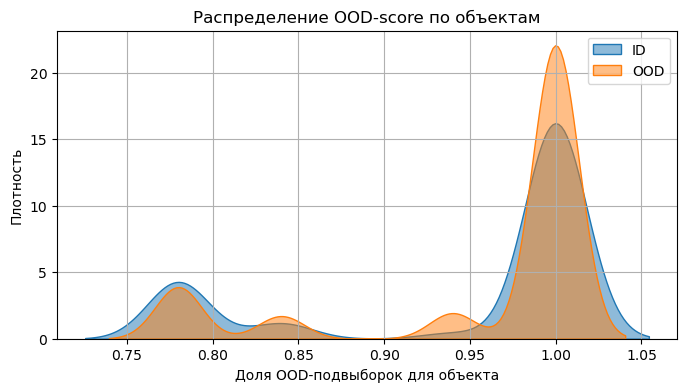

In [21]:
# эксперимент
dataset_name = "taxi" 

ID_df, OOD_df = load_dataset_pair(dataset_name)

res = fit_autoencoder_for_ood(
    ID_df,
    OOD_df,
    latent_dim=3,
    hidden_dims=[64, 32],
    batch_size=64,
    test_size=0.3,
    val_size=0.5,
    lr=1e-3,
    epochs=500,
    patience=30,
    random_state=42,
)

X_test_ID = res["X_test_ID"].reset_index(drop=True)
X_test_OOD = res["X_test_OOD"].reset_index(drop=True)

ID_errors = res["ID_errors"]
OOD_errors = res["OOD_errors"]

X_test_all = pd.concat([X_test_ID, X_test_OOD], axis=0).reset_index(drop=True)
errors_all = np.concatenate([ID_errors, OOD_errors], axis=0)
labels_all = np.array([0] * len(ID_errors) + [1] * len(OOD_errors))  # 0 = ID, 1 = OOD

bucket_results = ks_bucket_ood_scores(
    X=X_test_all,
    recon_errors=errors_all,
    ref_errors=ID_errors,
    m=50,
    n_bins=5,
    alpha=0.05,
    min_bucket_size=30,
    random_state=42,
)

scores = bucket_results["scores"]

print("Примеры объектов:")
for i in range(5):
    print(
        f"i={i}, label={labels_all[i]}, score={scores[i]:.3f}, "
        f"hits={bucket_results['ood_bucket_hits'][i]}, "
        f"times={bucket_results['times_in_buckets'][i]}"
    )

plt.figure(figsize=(8, 4))
sns.kdeplot(scores[labels_all == 0], label="ID", fill=True, alpha=0.5)
sns.kdeplot(scores[labels_all == 1], label="OOD", fill=True, alpha=0.5)
plt.xlabel("Доля OOD-подвыборок для объекта")
plt.ylabel("Плотность")
plt.title("Распределение OOD-score по объектам")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
results_df = pd.DataFrame({
    'label': labels_all,
    'score': scores,
})

results_df['label'] = results_df['label'].map({0: 'ID', 1: 'OOD'})

print("=" * 70)
print("РЕЗУЛЬТАТЫ ДЛЯ ВСЕГО ТЕСТОВОГО НАБОРА")
print("=" * 70)
print(f"Всего объектов: {len(results_df)}")
print(f"ID объектов: {(results_df['label'] == 'ID').sum()}")
print(f"OOD объектов: {(results_df['label'] == 'OOD').sum()}")
print()

print(results_df.to_string(index=True))

print("\n" + "=" * 70)
print("СТАТИСТИКА ПО ГРУППАМ")
print("=" * 70)
print("\nID объекты:")
print(results_df[results_df['label'] == 'ID']['score'].describe())
print("\nOOD объекты:")
print(results_df[results_df['label'] == 'OOD']['score'].describe())

РЕЗУЛЬТАТЫ ДЛЯ ВСЕГО ТЕСТОВОГО НАБОРА
Всего объектов: 10000
ID объектов: 3000
OOD объектов: 7000

     label  score
0       ID   1.00
1       ID   1.00
2       ID   0.72
3       ID   0.92
4       ID   0.88
5       ID   0.84
6       ID   0.92
7       ID   0.72
8       ID   0.88
9       ID   0.76
10      ID   0.72
11      ID   0.92
12      ID   0.72
13      ID   0.92
14      ID   0.92
15      ID   0.72
16      ID   1.00
17      ID   1.00
18      ID   0.72
19      ID   0.84
20      ID   0.72
21      ID   0.84
22      ID   0.88
23      ID   0.72
24      ID   0.84
25      ID   0.88
26      ID   1.00
27      ID   0.76
28      ID   0.92
29      ID   1.00
30      ID   0.84
31      ID   1.00
32      ID   0.88
33      ID   0.72
34      ID   0.92
35      ID   0.88
36      ID   0.92
37      ID   0.72
38      ID   0.80
39      ID   0.84
40      ID   0.92
41      ID   0.72
42      ID   1.00
43      ID   1.00
44      ID   0.88
45      ID   0.76
46      ID   0.88
47      ID   0.88
48      ID   0.88
49